In [1]:
#from data import load_data
%load_ext autoreload
%autoreload 2
import numpy as np
import json
import os
import matplotlib.pyplot as plt

In [2]:
embeddings = np.load('logs/2026_6_24/2/embeddings.npy')
print(embeddings.shape)

(19391, 20)


Text(0.5, 1.0, 'Training loss')

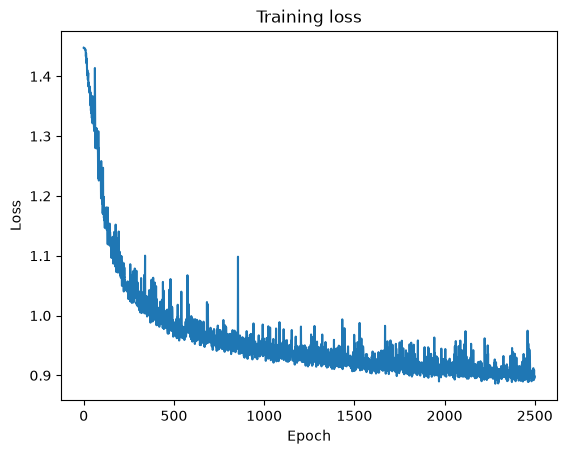

In [3]:
with open(os.path.join("logs/2026_6_24/2", 'metrics.json'), 'r') as f:
    results = json.load(f)

plt.plot(results['train_losses'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss')

Text(0, 0.5, 'MAP')

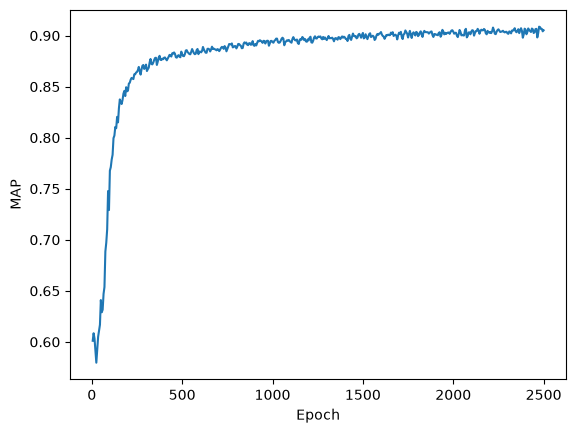

In [4]:
epochs = [m['epoch'] for m in results['val_metrics']]
maps = [m['ap'] for m in results['val_metrics']]  # ou 'ap' selon ce que retourne compute_metrics

plt.plot(epochs, maps)
plt.xlabel('Epoch')
plt.ylabel('MAP')

Text(0.5, 1.0, 'Distribution des normes dans B^n')

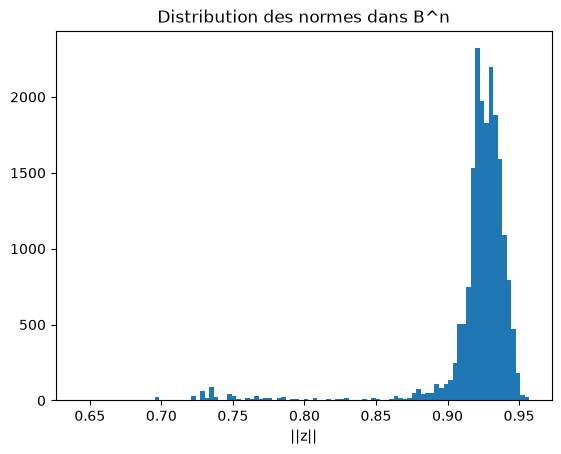

In [5]:
norms = np.linalg.norm(embeddings, axis=1)

plt.hist(norms, bins=100)
plt.xlabel('||z||')
plt.title('Distribution des normes dans B^n')

In [4]:
import OT
import poincare
from load_data import *

manifold = poincare.PoincareManifold()
nodes = list(G_hpo_work.nodes())
node2idx = {n: i for i, n in enumerate(nodes)}

C = OT.compute_costs_matrix_wasserstein2(work_omim, work_orpha, node2idx, embeddings, manifold, c=1.)

/home/onyxia/work/OT_simulation_maladies/HGCN/load_data.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  profils_omim = profils_omim.reset_index()


Precompute...
Finished !
Precomputing full HPO distance matrix...


Distance matrix rows: 100%|██████████| 42/42 [00:36<00:00,  1.15it/s]


HPO distance matrix: (10649, 10649)


OMIM:  60%|█████▉    | 3915/6562 [13:14<08:56,  4.93it/s]

KeyboardInterrupt: 